# Credit Default Classification — ML Training & Evaluation Notebook

**Objetivo:** Treinar, avaliar e salvar modelos de machine learning para classificação binária de inadimplência de crédito.

**Estrutura:**
1. Parametrização
2. Importação de Bibliotecas
3. Carregamento dos Dados
4. Pré-processamento
5. Split Temporal
6. Treinamento dos Modelos
7. Avaliação & Métricas
8. Integração com MLflow
9. Visualizações
10. Comparação Final de Modelos

> **Split 100% temporal** — Nenhum split aleatório é utilizado.

---
## 1. Parametrização

Configure aqui todas as variáveis do experimento. **Não altere células abaixo sem antes ajustar estes parâmetros.**

In [1]:
# =============================================================================
# PARÂMETROS GLOBAIS DO EXPERIMENTO
# =============================================================================

# --- Alvo e features ---
TARGET = "ever30mob6"                         # Nome da coluna alvo (binária: 0/1)
COL_TO_DUMMIES = ["tipo_moradia", "tipo_cliente", "nivel_educacao", 'tipo_contrato', 'com_prod_canal', 'canal_venda'] # Colunas categóricas para one-hot encoding

# --- Coluna de data e datas de corte (formato: 'YYYY-MM-DD') ---
DATE_COL = "data_safra"                          # Coluna de data para split temporal


# --- Reprodutibilidade ---
RANDOM_STATE = 42


# --- Visualização ---
TREE_PLOT_DEPTH = 3  # Profundidade máxima para plot da árvore
FIG_DPI = 120

print("Parâmetros carregados com sucesso.")
print(f"   Target       : {TARGET}")

Parâmetros carregados com sucesso.
   Target       : ever30mob6


---
## 2. Importação de Bibliotecas

In [2]:
# --- Manipulação de dados ---
import pandas as pd
import numpy as np

# --- Modelagem ---
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder

# --- Métricas ---
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)
from scipy import stats

# --- Visualização ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- Utilitários ---
import warnings
import os
import json
from datetime import datetime

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_STATE)

# Estilo dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = FIG_DPI

print("Bibliotecas importadas com sucesso.")
print(f"   Pandas versão : {pd.__version__}")


def compute_woe(df, feature, target, bins=10, smoothing=0.5):

    df = df[[feature, target]].copy()

    # Binning (numérico)
    if pd.api.types.is_numeric_dtype(df[feature]):
        df["bin"] = pd.qcut(df[feature], q=bins, duplicates="drop")
    else:
        df["bin"] = df[feature].astype(str)

    grouped = df.groupby("bin")[target].agg(["count", "sum"])
    grouped.columns = ["total", "bad"]

    grouped["good"] = grouped["total"] - grouped["bad"]

    total_good = grouped["good"].sum()
    total_bad = grouped["bad"].sum()

    # smoothing para evitar divisão por zero
    grouped["dist_good"] = (grouped["good"] + smoothing) / (total_good + smoothing * len(grouped))
    grouped["dist_bad"]  = (grouped["bad"]  + smoothing) / (total_bad  + smoothing * len(grouped))

    grouped["woe"] = np.log(grouped["dist_good"] / grouped["dist_bad"])

    woe_map = grouped["woe"].to_dict()

    return woe_map, grouped

def apply_woe(df, feature, woe_map, bins=10):

    if pd.api.types.is_numeric_dtype(df[feature]):
        binned = pd.qcut(df[feature], q=bins, duplicates="drop")
        return binned.map(woe_map)
    else:
        return df[feature].astype(str).map(woe_map)

Bibliotecas importadas com sucesso.
   Pandas versão : 2.3.3


---
## 3. Carregamento dos Dados

Por padrão, usamos o dataset público **UCI Credit Card Default** como exemplo.
Substitua a célula de leitura pelo seu próprio dataset — o restante do notebook se adapta automaticamente.

In [3]:
df = pd.read_parquet('data/model.parquet')

df = df[df['data_safra'] > '2021-05-31']

print(f"Shape do dataset: {df.shape}")
print(f"Período: {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}")
print(f"Distribuição do target ({TARGET}):")
print(df[TARGET].value_counts(normalize=True).rename({0: 'Adimplente (0)', 1: 'Inadimplente (1)'}).to_string())
df.head()
df.info()

Shape do dataset: (65990, 27)
Período: 2021-06-01 → 2024-12-23
Distribuição do target (ever30mob6):
ever30mob6
Adimplente (0)      0.994242
Inadimplente (1)    0.005758
<class 'pandas.core.frame.DataFrame'>
Index: 65990 entries, 0 to 107418
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id_contrato                 65990 non-null  int64         
 1   id_cliente                  65990 non-null  int64         
 2   ever30mob3                  65990 non-null  int64         
 3   ever30mob6                  65990 non-null  int64         
 4   ever30mob9                  65990 non-null  int64         
 5   ever30mob12                 65990 non-null  int64         
 6   ever30mob24                 65990 non-null  int64         
 7   max_mob                     65990 non-null  float64       
 8   renda_anual                 65990 non-null  float64       
 9   qtd_filhos       

In [4]:
# --- Checagem de missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).query("`Missing Count` > 0")

if missing_report.empty:
    print("Nenhum valor ausente encontrado.")
else:
    print("Colunas com valores ausentes:")
    display(missing_report)
    
# --- Tipos de dados ---
print("\nTipos de dados:")
print(df.dtypes.to_string())

Colunas com valores ausentes:


,Missing Count,Missing %
valor_bem,1770,2.68
valor_parcela,1,0.00



Tipos de dados:
id_contrato                            int64
id_cliente                             int64
ever30mob3                             int64
ever30mob6                             int64
ever30mob9                             int64
ever30mob12                            int64
ever30mob24                            int64
max_mob                              float64
renda_anual                          float64
qtd_filhos                             int64
possui_carro                          object
possui_imovel                         object
nivel_educacao                        object
tipo_moradia                          object
valor_credito                        float64
tipo_cliente                          object
valor_bem                            float64
valor_parcela                        float64
tipo_contrato                         object
nota_regiao_cliente                    int64
nota_regiao_cliente_cidade             int64
canal_venda                           

In [5]:
df['valor_bem'] = df['valor_bem'].fillna(0)
df['valor_parcela'] = df['valor_parcela'].fillna(0)

In [6]:
# --- Estatísticas descritivas ---
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_contrato,65990.0,NaN,NaN,NaN,1906900.0374,1000003.0,1435992.5,1899352.0,2370285.75,2843493.0,535998.810723
id_cliente,65990.0,NaN,NaN,NaN,278257.672102,100023.0,190251.25,278568.0,366573.75,456248.0,102261.347537
ever30mob3,65990.0,NaN,NaN,NaN,0.002682,0.0,0.0,0.0,0.0,1.0,0.051721
ever30mob6,65990.0,NaN,NaN,NaN,0.005758,0.0,0.0,0.0,0.0,1.0,0.075666
ever30mob9,65990.0,NaN,NaN,NaN,0.00835,0.0,0.0,0.0,0.0,1.0,0.090995
ever30mob12,65990.0,NaN,NaN,NaN,0.010244,0.0,0.0,0.0,0.0,1.0,0.100694
ever30mob24,65990.0,NaN,NaN,NaN,0.011699,0.0,0.0,0.0,0.0,1.0,0.107527
max_mob,65990.0,NaN,NaN,NaN,10.473496,2.0,6.0,9.0,12.0,45.0,6.684991
renda_anual,65990.0,NaN,NaN,NaN,172919.365524,26100.0,112500.0,157500.0,202500.0,117000000.0,476867.090809
qtd_filhos,65990.0,NaN,NaN,NaN,0.413745,0.0,0.0,0.0,1.0,14.0,0.720945


---
## 4. Pré-processamento

In [7]:
# =============================================================================
# 4.1 — Conversão de data e ordenação temporal
# =============================================================================

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

print(f"Coluna '{DATE_COL}' convertida para datetime e dataset ordenado temporalmente.")
print(f"Período: {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}")

Coluna 'data_safra' convertida para datetime e dataset ordenado temporalmente.
Período: 2021-06-01 → 2024-12-23


In [8]:
# =============================================================================
# 4.2 — One-Hot Encoding nas colunas categóricas
# =============================================================================

cols_existing = [c for c in COL_TO_DUMMIES if c in df.columns]
cols_missing  = [c for c in COL_TO_DUMMIES if c not in df.columns]

if cols_missing:
    print(f"⚠️  Colunas não encontradas (ignoradas): {cols_missing}")

if cols_existing:
    df = pd.get_dummies(df, columns=cols_existing, drop_first=True, dtype=int)
    print(f"One-hot encoding aplicado em: {cols_existing}")
    print(f"   Shape após encoding: {df.shape}")
else:
    print("Nenhuma coluna para encoding.")

One-hot encoding aplicado em: ['tipo_moradia', 'tipo_cliente', 'nivel_educacao', 'tipo_contrato', 'com_prod_canal', 'canal_venda']
   Shape após encoding: (65990, 45)


In [9]:
# =============================================================================
# 4.3 — Separação entre features (X) e target (y)
# =============================================================================

# Remover coluna de data e target das features

X = df.copy()
y = df[TARGET].copy()
dates_series = df[DATE_COL].copy()

print(f"Features separadas.")
print(f"   X shape : {X.shape}")
print(f"   y shape : {y.shape}")

Features separadas.
   X shape : (65990, 45)
   y shape : (65990,)


---
## 5. Split Temporal

> **Regra de ouro:** Nenhum dado futuro vaza para o passado.
>
> - **Treino** : `date ≤ TRAIN_END_DATE`
> - **Validação**: `TRAIN_END_DATE < date ≤ VAL_END_DATE`
> - **Teste** : `date > VAL_END_DATE`

In [10]:
TRAIN_END_DATE = "2024-03-31"              # Data final do período de treino
VAL_END_DATE   = "2024-06-01"
END_DATE = '2025-12-02'

train_end = pd.to_datetime(TRAIN_END_DATE)
val_end   = pd.to_datetime(VAL_END_DATE)
end_date   = pd.to_datetime(END_DATE)
# Máscaras temporais
mask_train = dates_series <= train_end
mask_test   = (dates_series > train_end) & (dates_series <= val_end)
mask_val = (dates_series > val_end) & (dates_series < end_date)

# Splits
X_train, y_train = X[mask_train], y[mask_train]
X_val,   y_val   = X[mask_val],   y[mask_val]
X_test,  y_test  = X[mask_test],  y[mask_test]

# Validação: tamanho mínimo
for name, X_part, y_part in [("Treino", X_train, y_train),
                               ("Validação", X_val, y_val),
                               ("Teste", X_test, y_test)]:
    if len(X_part) == 0:
        raise ValueError(f"⛔ Conjunto de {name} está vazio! Revise as datas de corte.")

print("Split temporal concluído:")
print(f"   {'Conjunto':<12} {'Amostras':>10} {'Default %':>12} {'Período'}")
print(f"   {'-'*55}")
for name, X_s, y_s, d_s in [
    ("Treino",    X_train, y_train, dates_series[mask_train]),
    ("Teste",     X_test,  y_test,  dates_series[mask_test]),
    ("Validação", X_val,   y_val,   dates_series[mask_val])

]:
    pct = y_s.mean() * 100
    print(f"   {name:<12} {len(X_s):>10,} {pct:>11.1f}%   {d_s.min().date()} → {d_s.max().date()}")

Split temporal concluído:
   Conjunto       Amostras    Default % Período
   -------------------------------------------------------
   Treino           51,815         0.7%   2021-06-01 → 2024-03-31
   Teste             4,316         0.4%   2024-04-01 → 2024-06-01
   Validação         9,859         0.2%   2024-06-02 → 2024-12-23


cria colunas com WoE

In [11]:
feature = "valor_parcela"

woe_map, table = compute_woe(X_train, feature, TARGET)

X_train[f"{feature}_woe"] = apply_woe(X_train, feature, woe_map).astype(float).fillna(0)
X_test[f"{feature}_woe"]   = apply_woe(X_test, feature, woe_map).astype(float).fillna(0)
X_val[f"{feature}_woe"]  = apply_woe(X_val, feature, woe_map).astype(float).fillna(0)

In [12]:
feature = "valor_bem"

woe_map, table = compute_woe(X_train, feature, TARGET)

X_train[f"{feature}_woe"] = apply_woe(X_train, feature, woe_map).astype(float).fillna(0)
X_test[f"{feature}_woe"]   = apply_woe(X_test, feature, woe_map).astype(float).fillna(0)
X_val[f"{feature}_woe"]  = apply_woe(X_val, feature, woe_map).astype(float).fillna(0)

In [13]:
feature = "valor_credito"

woe_map, table = compute_woe(X_train, feature, TARGET)

X_train[f"{feature}_woe"] = apply_woe(X_train, feature, woe_map).astype(float).fillna(0)
X_test[f"{feature}_woe"]   = apply_woe(X_test, feature, woe_map).astype(float).fillna(0)
X_val[f"{feature}_woe"]  = apply_woe(X_val, feature, woe_map).astype(float).fillna(0)

In [14]:
feature = "renda_anual"

woe_map, table = compute_woe(X_train, feature, TARGET)

X_train[f"{feature}_woe"] = apply_woe(X_train, feature, woe_map).astype(float).fillna(0)
X_test[f"{feature}_woe"]   = apply_woe(X_test, feature, woe_map).astype(float).fillna(0)
X_val[f"{feature}_woe"]  = apply_woe(X_val, feature, woe_map).astype(float).fillna(0)

In [15]:
feature = "qtd_filhos"

woe_map, table = compute_woe(X_train, feature, TARGET)

X_train[f"{feature}_woe"] = apply_woe(X_train, feature, woe_map).astype(float).fillna(0)
X_test[f"{feature}_woe"]   = apply_woe(X_test, feature, woe_map).astype(float).fillna(0)
X_val[f"{feature}_woe"]  = apply_woe(X_val, feature, woe_map).astype(float).fillna(0)

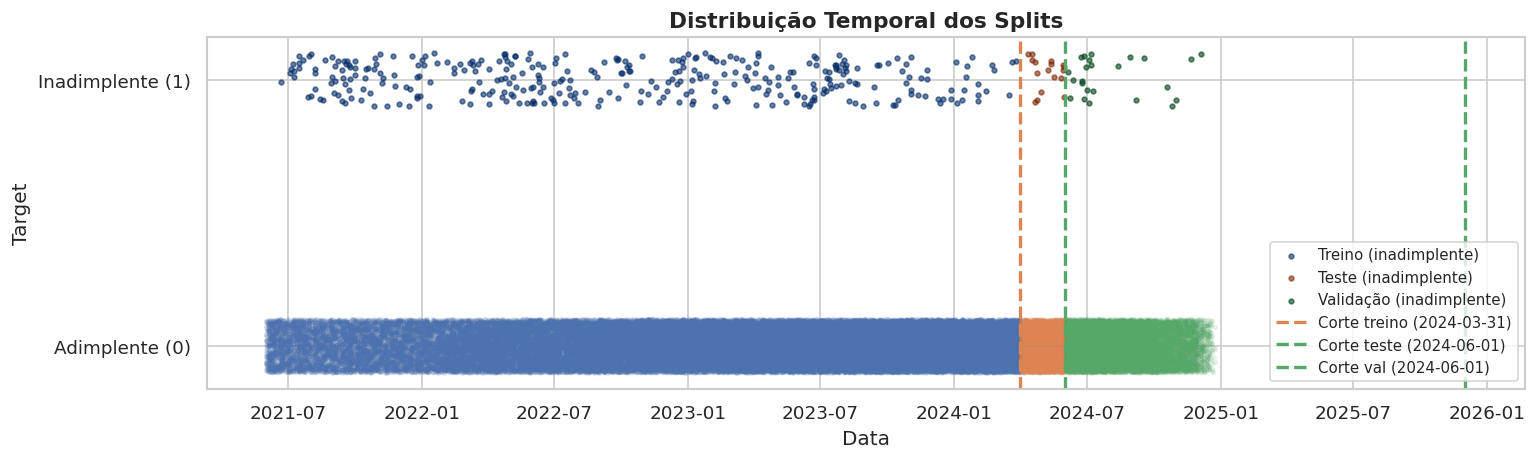

In [16]:
# --- Visualização da distribuição temporal ---
fig, ax = plt.subplots(figsize=(13, 4))

bins_monthly = pd.cut(dates_series, bins=12)
split_labels = pd.Series("Treino", index=df.index)
split_labels[mask_val]  = "Validação"
split_labels[mask_test] = "Teste"

colors_good = {"Treino": "#4C72B0", "Validação": "#55A868", "Teste": "#DD8452"}
colors_bad  = {"Treino": "#08306B", "Validação": "#00441B", "Teste": "#7F2704"}

for split in ["Treino", "Teste", "Validação"]:

    mask_split = split_labels == split

    # Bons (0)
    mask_good = mask_split & (y == 0)
    ax.scatter(
        dates_series[mask_good],
        y[mask_good] + np.random.uniform(-0.1, 0.1, mask_good.sum()),
        c=colors_good[split],
        alpha=0.1,
        s=5
    )

    # Maus (1) → mais fortes
    mask_bad = mask_split & (y == 1)
    ax.scatter(
        dates_series[mask_bad],
        y[mask_bad] + np.random.uniform(-0.1, 0.1, mask_bad.sum()),
        c=colors_bad[split],
        alpha=0.6,
        s=8,
        label=f"{split} (inadimplente)"
    )
    
ax.axvline(train_end, color="#DD8452", linestyle="--", lw=2, label=f"Corte treino ({TRAIN_END_DATE})")
ax.axvline(val_end,   color="#55A868", linestyle="--", lw=2, label=f"Corte teste ({VAL_END_DATE})")
ax.axvline(end_date,   color="#55A868", linestyle="--", lw=2, label=f"Corte val ({VAL_END_DATE})")
ax.set_title("Distribuição Temporal dos Splits", fontsize=13, fontweight="bold")
ax.set_xlabel("Data")
ax.set_ylabel("Target")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Adimplente (0)", "Inadimplente (1)"])
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Treinamento dos Modelos

In [17]:
features = [
    'tipo_moradia_Municipal apartment',
    'tipo_moradia_Office apartment',
    'tipo_moradia_Rented apartment',
    'tipo_moradia_With parents',
    'tipo_contrato_Consumer loans',
    'tipo_contrato_Revolving loans',
    'valor_parcela_woe',
    'valor_bem_woe',
    'valor_credito_woe',
    'renda_anual_woe',
    'qtd_filhos_woe',
    #    'com_prod_canal_industry', 
    # 'com_prod_canal_mobile',
    #    'com_prod_canal_others', 
    # 'com_prod_canal_street',
    #    'com_prod_canal_x-sell',
    # 'canal_venda_Car dealer',
    #    'canal_venda_Channel of corporate sales', 
    # 'canal_venda_Contact center',
    #    'canal_venda_Country-wide',
    # 'canal_venda_Credit and cash offices',
    #    'canal_venda_Regional / Local',
    # 'canal_venda_Stone',

]


In [18]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, IsolationForest
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score

# =============================================================================
# 0. Wrapper para IsolationForest (adapta para interface de classificador)
# =============================================================================
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score
from sklearn.utils.validation import check_is_fitted

param_grids = {
    "DecisionTree": {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 10, 20],
        "min_samples_leaf": [1, 5, 10],
        "class_weight": ["balanced", None],
        "criterion": ["gini", "entropy"]
    },

    "LGBMClassifier": {
        "n_estimators": [300, 500, 1000],
        "learning_rate": [0.01, 0.05, 0.001],
        "num_leaves": [20, 31, 50],
        "min_child_samples": [5, 10, 20],
        "scale_pos_weight": [50, 100, 300, 500],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
        "boosting_type": ['gbdt', 'dart'],
    },

    "RandomForest": {
        "n_estimators": [200, 400, 600],
        "max_depth": [5, 8, 12, None],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.3],
        "class_weight": ["balanced", "balanced_subsample"]
    },

    "XGBClassifier": {
        "n_estimators": [300, 500, 1000],
        "max_depth": [3, 6, 9],
        "scale_pos_weight": [50, 100, 300, 500],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
        "min_child_weight": [1, 5, 10],
        "gamma": [0, 0.1, 0.5],
    },

    "BalancedRandomForest": {
        "n_estimators": [200, 400],
        "max_depth": [None, 10, 15],
        "min_samples_leaf": [1, 2],
        "sampling_strategy": ['auto', 0.1, 0.3]
    },

    "HistGradientBoosting": {
        "max_iter": [200, 500],
        "max_depth": [5, 10, None],
        "learning_rate": [0.01, 0.05, 0.1],
        "min_samples_leaf": [10, 20, 50],
        "l2_regularization": [0, 0.1, 1.0],
        "class_weight": ["balanced"]
    },
}

# =============================================================================
# 2. Mapa de modelos
# =============================================================================
model_map = {
    "DecisionTree": DecisionTreeClassifier(),
    "LGBMClassifier": LGBMClassifier(verbosity=-1),
    "RandomForest": RandomForestClassifier(),
    "XGBClassifier": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "BalancedRandomForest": BalancedRandomForestClassifier(),
    "HistGradientBoosting": HistGradientBoostingClassifier(),
}

# =============================================================================
# 2. Otimização e Treinamento
# =============================================================================
BEST_MODELS = {}
RANDOM_STATE = 42 # Certifique-se de ter essa variável definida

print("Iniciando Otimização de Hiperparâmetros...")

for name, params in param_grids.items():
    print(f"--- Otimizando {name} ---")
    
    # Busca a instância do modelo no mapa que criamos
    base_model = model_map[name]
    from sklearn.model_selection import StratifiedKFold
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=params,
        n_iter=8,           
        cv=cv,                
        scoring='f1',        # roc_auc
        n_jobs=1,           
        random_state=RANDOM_STATE,
        verbose=3
    )
    
    search.fit(X_train[features], y_train)
    
    BEST_MODELS[name] = {
        "model": search.best_estimator_,
        "params": search.best_params_,
        "score": search.best_score_
    }
    
    print(f"Melhor f1 score para {name}: {search.best_score_:.4f}\n")
    print(50*'-')
# Re-treinamento final (opcional, pois o best_estimator_ já vem treinado com o melhor fold)
print("🚀 Finalizando modelos...")
for name, config in BEST_MODELS.items():
    # O search.best_estimator_ já está fitado, mas se quiser garantir:
    config["model"].fit(X_train[features], y_train)
    print(f"    ✅ {name} pronto para predição.")

print("\nTodos os modelos robustos treinados com sucesso!")

Iniciando Otimização de Hiperparâmetros...
--- Otimizando DecisionTree ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END class_weight=None, criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=2;, score=0.000 total time=   0.0s
[CV 2/5] END class_weight=None, criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=2;, score=0.000 total time=   0.0s
[CV 3/5] END class_weight=None, criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=2;, score=0.000 total time=   0.0s
[CV 4/5] END class_weight=None, criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=2;, score=0.000 total time=   0.0s
[CV 5/5] END class_weight=None, criterion=entropy, max_depth=5, min_samples_leaf=1, min_samples_split=2;, score=0.000 total time=   0.0s
[CV 1/5] END class_weight=balanced, criterion=gini, max_depth=10, min_samples_leaf=1, min_samples_split=10;, score=0.016 total time=   0.0s
[CV 2/5] END class_weight=balanced, crit

---
## 7. Funções de Métricas

Definição centralizada de todas as funções de avaliação, incluindo o **KS (Kolmogorov-Smirnov)**.

In [19]:
# =============================================================================
# FUNÇÕES DE MÉTRICAS
# =============================================================================

def compute_ks(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """
    Calcula a estatística KS (Kolmogorov-Smirnov).
    
    O KS mede a máxima separação entre as distribuições cumulativas
    de scores para positivos (inadimplentes) e negativos (adimplentes).
    
    Parâmetros
    ----------
    y_true : array de labels reais (0/1)
    y_prob : array de probabilidades previstas para a classe 1
    
    Retorna
    -------
    float : estatística KS no intervalo [0, 1]
    """
    # Separar scores por classe
    scores_pos = y_prob[y_true == 1]  # Inadimplentes
    scores_neg = y_prob[y_true == 0]  # Adimplentes
    
    # Estatística KS via scipy (two-sample KS test)
    ks_stat, _ = stats.ks_2samp(scores_pos, scores_neg)
    return ks_stat


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray,
                    threshold: float = 0.5) -> dict:
    """
    Computa todas as métricas de avaliação para classificação binária.
    """
    y_pred = (y_prob >= threshold).astype(int)
    
    # Cálculo da AUC primeiro para derivar o Gini
    auc_score = roc_auc_score(y_true, y_prob)
    gini_score = 2 * auc_score - 1
    
    return {
        "auc"      : auc_score,
        "gini"     : gini_score, # Adicionado aqui
        "ks"       : compute_ks(y_true, y_prob),
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall"   : recall_score(y_true, y_pred, zero_division=0),
        "f1"       : f1_score(y_true, y_pred, zero_division=0)
    }

def evaluate_model(model, X_val, y_val, X_test, y_test) -> dict:
    """
    Avalia um modelo treinado nos conjuntos de validação e teste.
    Retorna dicionário com métricas e probabilidades previstas.
    """
    y_prob_val  = model.predict_proba(X_val)[:, 1]
    y_prob_test = model.predict_proba(X_test)[:, 1]
    
    metrics_val  = compute_metrics(y_val,  y_prob_val)
    metrics_test = compute_metrics(y_test, y_prob_test)
    
    return {
        "val" : metrics_val,
        "test": metrics_test,
        "y_prob_val" : y_prob_val,
        "y_prob_test": y_prob_test
    }


def print_metrics_table(metrics_val: dict, metrics_test: dict, model_name: str):
    """Imprime tabela formatada de métricas."""
    print(f"\n{'='*55}")
    print(f" Modelo: {model_name}")
    print(f"{'='*55}")
    print(f" {'Métrica':<12} {'Validação':>12} {'Teste':>12}")
    print(f" {'-'*38}")
    for key in ["auc", 'gini', "ks", "accuracy", "precision", "recall", "f1"]:
        v = metrics_val.get(key, float('nan'))
        t = metrics_test.get(key, float('nan'))
        print(f" {key.capitalize():<12} {v:>12.4f} {t:>12.4f}")
    print(f"{'='*55}")


print("Funções de métricas definidas (KS, AUC, Accuracy, Precision, Recall, F1).")

Funções de métricas definidas (KS, AUC, Accuracy, Precision, Recall, F1).


In [20]:
import matplotlib.pyplot as plt


RESULTS = {}

for name, config in BEST_MODELS.items():

    model = config["model"]

    results = evaluate_model(
        model, X_val[features], y_val, X_test[features], y_test
    )
    RESULTS[name] = results

    print_metrics_table(results["val"], results["test"], name)


 Modelo: DecisionTree
 Métrica         Validação        Teste
 --------------------------------------
 Auc                0.5551       0.6001
 Gini               0.1102       0.2002
 Ks                 0.1336       0.2198
 Accuracy           0.5504       0.5730
 Precision          0.0032       0.0060
 Recall             0.5833       0.6471
 F1                 0.0063       0.0118

 Modelo: LGBMClassifier
 Métrica         Validação        Teste
 --------------------------------------
 Auc                0.5453       0.4870
 Gini               0.0906      -0.0259
 Ks                 0.1399       0.1912
 Accuracy           0.7726       0.7486
 Precision          0.0027       0.0009
 Recall             0.2500       0.0588
 F1                 0.0053       0.0018

 Modelo: RandomForest
 Métrica         Validação        Teste
 --------------------------------------
 Auc                0.4495       0.2506
 Gini              -0.1010      -0.4987
 Ks                 0.1823       0.4449
 Accuracy

---
## 8.  ROC AUC PLOT

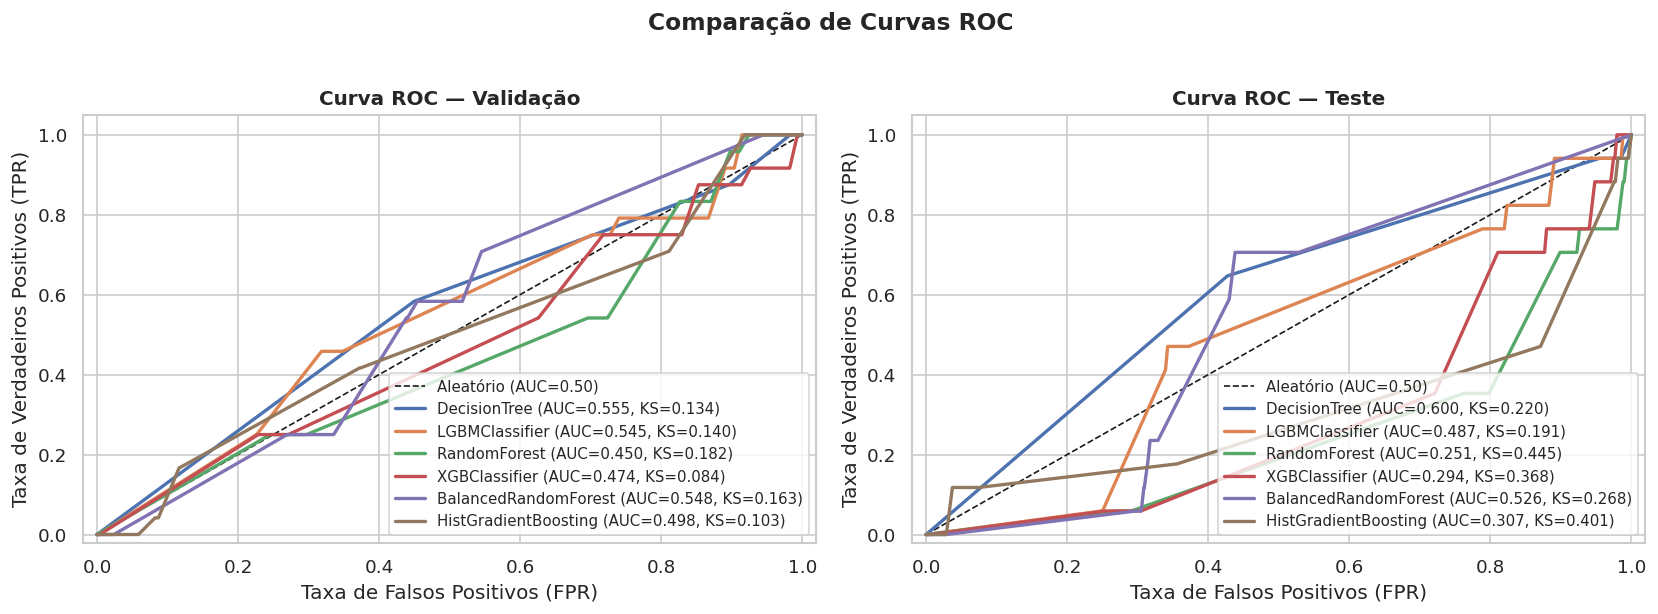

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
PALETTE = [
    "#4C72B0",  # azul
    "#DD8452",  # laranja
    "#55A868",  # verde
    "#C44E52",  # vermelho
    "#8172B3",  # roxo
    "#937860",  # marrom
    "#DA8BC3",  # rosa
]

for ax, (split_key, y_true, split_label) in zip(
    axes,
    [("val", y_val, "Validação"), ("test", y_test, "Teste")]
):
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatório (AUC=0.50)")
    
    for (model_name, results), color in zip(RESULTS.items(), PALETTE):
        y_prob = results[f"y_prob_{split_key}"]
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = results[split_key]["auc"]
        ks  = results[split_key]["ks"]
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{model_name} (AUC={auc:.3f}, KS={ks:.3f})")
    
    ax.set_title(f"Curva ROC — {split_label}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Taxa de Falsos Positivos (FPR)")
    ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])

plt.suptitle("Comparação de Curvas ROC", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Comparação Final de Modelos

In [22]:
# =============================================================================
# Construção do DataFrame de comparação
# =============================================================================

rows = []
for model_name, results in RESULTS.items():
    for split in ["val", "test"]:
        row = {"model": model_name, "split": split.upper()}
        row.update(results[split])
        rows.append(row)

comparison_df = pd.DataFrame(rows)

# Formatação para exibição
metrics_cols = ["auc", "ks", "accuracy", "precision", "recall", "f1"]
comparison_display = comparison_df.copy()
comparison_display[metrics_cols] = comparison_display[metrics_cols].round(4)

# Ordenar por f1 no conjunto de teste
val_comparison = (
    comparison_display[comparison_display.split == "VAL"]
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)
test_comparison = (
    comparison_display[comparison_display.split == "TEST"]
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

print("\n📊 COMPARAÇÃO — VALIDAÇÃO")
print(val_comparison[["model"] + metrics_cols].to_string(index=False))

print("\n📊 COMPARAÇÃO — TESTE")
print(test_comparison[["model"] + metrics_cols].to_string(index=False))


📊 COMPARAÇÃO — VALIDAÇÃO
               model    auc     ks  accuracy  precision  recall     f1
        DecisionTree 0.5551 0.1336    0.5504     0.0032  0.5833 0.0063
      LGBMClassifier 0.5453 0.1399    0.7726     0.0027  0.2500 0.0053
        RandomForest 0.4495 0.1823    0.9976     0.0000  0.0000 0.0000
       XGBClassifier 0.4743 0.0843    0.9961     0.0000  0.0000 0.0000
BalancedRandomForest 0.5478 0.1629    0.9976     0.0000  0.0000 0.0000
HistGradientBoosting 0.4982 0.1029    0.9787     0.0000  0.0000 0.0000

📊 COMPARAÇÃO — TESTE
               model    auc     ks  accuracy  precision  recall     f1
        DecisionTree 0.6001 0.2198    0.5730     0.0060  0.6471 0.0118
      LGBMClassifier 0.4870 0.1912    0.7486     0.0009  0.0588 0.0018
        RandomForest 0.2506 0.4449    0.9961     0.0000  0.0000 0.0000
       XGBClassifier 0.2937 0.3684    0.9947     0.0000  0.0000 0.0000
BalancedRandomForest 0.5259 0.2679    0.9961     0.0000  0.0000 0.0000
HistGradientBoosting 0.3066 0

In [23]:
# =============================================================================
# Identificação do melhor modelo (por AUC no teste)
# =============================================================================

best_model_name = test_comparison.iloc[0]["model"]
best_auc        = test_comparison.iloc[0]["auc"]
best_ks         = test_comparison.iloc[0]["ks"]

print("\n" + "=" * 50)
print(f"  🥇 MELHOR MODELO: {best_model_name}")
print(f"     AUC (Teste) : {best_auc:.4f}")
print(f"     KS  (Teste) : {best_ks:.4f}")
print("=" * 50)


  🥇 MELHOR MODELO: DecisionTree
     AUC (Teste) : 0.6001
     KS  (Teste) : 0.2198


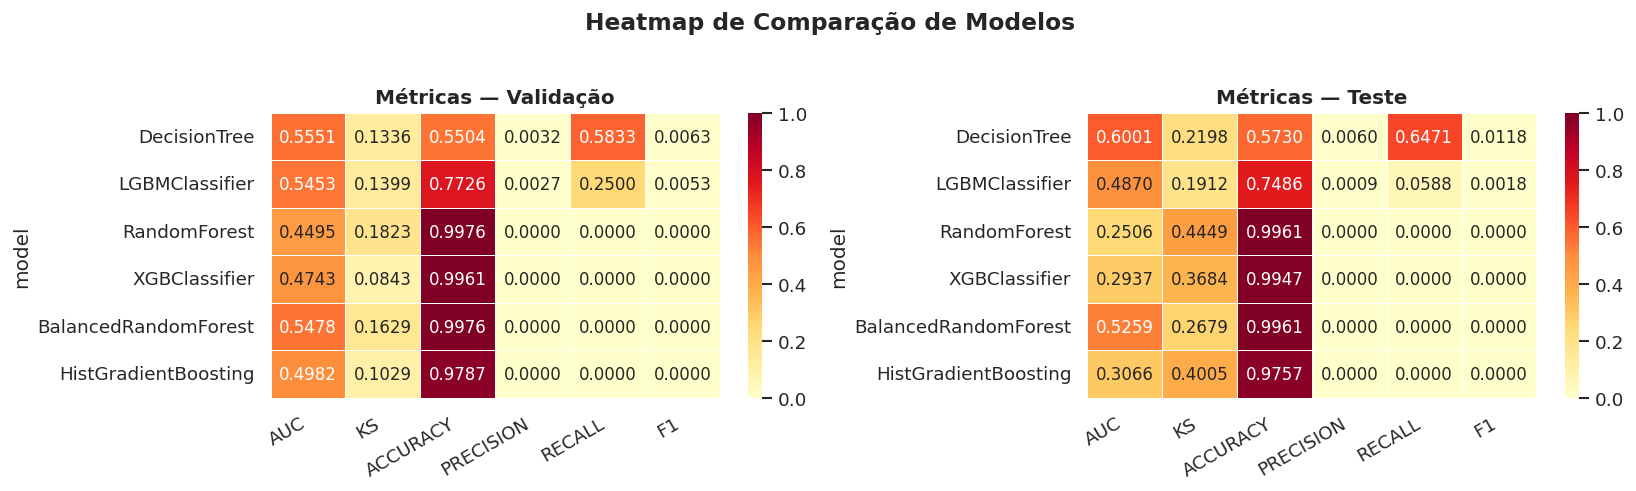

In [24]:
# --- Heatmap visual de comparação ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (title, subset) in zip(
    axes,
    [("Validação", val_comparison), ("Teste", test_comparison)]
):
    heat_data = subset.set_index("model")[metrics_cols]
    
    sns.heatmap(
        heat_data,
        annot=True,
        fmt=".4f",
        cmap="YlOrRd",
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        vmin=0,
        vmax=1,
        annot_kws={"size": 10}
    )
    ax.set_title(f"Métricas — {title}", fontsize=12, fontweight="bold")
    ax.set_xticklabels([m.upper() for m in metrics_cols], rotation=30, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle("Heatmap de Comparação de Modelos", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

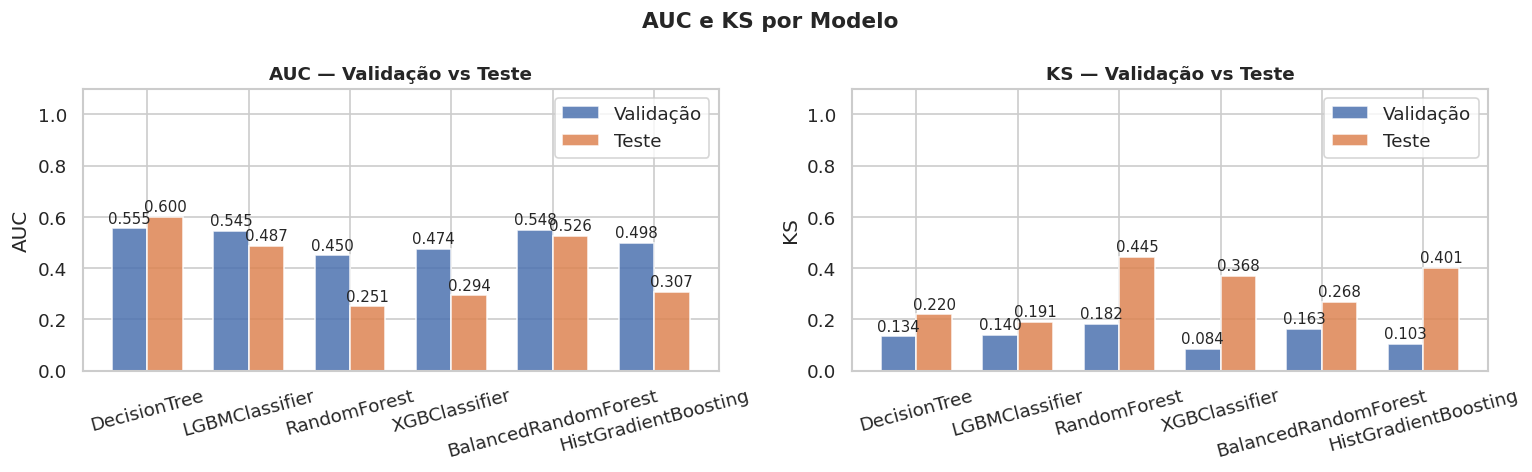

In [25]:
# --- Barplot de AUC e KS ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric in zip(axes, ["auc", "ks"]):
    models = test_comparison["model"].tolist()
    vals_val  = val_comparison.set_index("model")[metric].reindex(models).values
    vals_test = test_comparison.set_index("model")[metric].reindex(models).values
    
    x = np.arange(len(models))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, vals_val,  width, label="Validação", color="#4C72B0", alpha=0.85)
    bars2 = ax.bar(x + width/2, vals_test, width, label="Teste",     color="#DD8452", alpha=0.85)
    
    ax.set_title(f"{metric.upper()} — Validação vs Teste", fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.set_ylabel(metric.upper())
    ax.set_ylim(0, 1.1)
    ax.legend()
    
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.01,
                f"{h:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("AUC e KS por Modelo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Export

In [26]:
import json, pickle

os.makedirs("models", exist_ok=True)

# Salvar woe_maps (gerados durante o treino)
woe_maps_all = {}
for feat in ["valor_parcela", "valor_bem", "valor_credito", "renda_anual", "qtd_filhos"]:
    woe_map_feat, _ = compute_woe(X_train, feat, TARGET)
    woe_maps_all[feat] = {str(k): v for k, v in woe_map_feat.items()}

with open("models/woe_maps.json", "w") as f:
    json.dump(woe_maps_all, f, indent=2)

# Salvar melhor modelo
with open("models/best_model.pkl", "wb") as f:
    pickle.dump(BEST_MODELS[best_model_name]["model"], f)